# Breakpoints

For `human-in-the-loop`, we often want to see our graph outputs as its running.

We laid the foundations for this with streaming.


## Goals

Now, let's talk about the motivations for `human-in-the-loop`:

1) `Approval` - We can interrupt our agent, surface state to a user, and allow the user to accept an action.

2) `Debbuging` - We can rewind the graph to reproduce or avoid issues

3) `Editing` - You can modify the state


LangGraph offers several ways to get or update agent state to support various `human-in-the-loop` workflows.

First, we'll introduce `breakpoints`, which provide a simple way to stop the graph at specific steps.

We'll show how this enables user `approval`. 

In [1]:
import os, getpass

def _set_env(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"{var}: ")

_set_env("ANTHROPIC_API_KEY")

## Breakpoints for human approval

let's reconsider the simple agent that we worked with in Module 1.

Let's assume that are concerned about tool use: we want to approve the agent to use any of its tools.

All we need to do is simply compile the graph with `interrupt_before=["tools"]` where `tools` is our tools node.

This means that the execution will be interrupted before the node `tools`, which executes the tool call.

In [2]:
from langchain_anthropic import ChatAnthropic

def multiply(a: int, b: int) -> int:
    """Multiply a and b.

    Args:
        a: first int
        b: second int
    """
    return a * b

# This will be a tool
def add(a: int, b: int) -> int:
    """Adds a and b

    Args:
        a: first int
        b: second int    
    """
    return a + b

def divide(a: int, b: int) -> float:
    """Divide a and b
    
    Args:
        a: first int
        b: second int
    """
    return a / b


tools = [multiply, add, divide]
llm = ChatAnthropic(model="claude-haiku-4-5")
llm_with_tools = llm.bind_tools(tools)

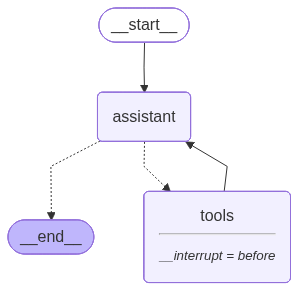

In [3]:
from IPython.display import Image, display
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import MessagesState
from langgraph.graph import START, StateGraph
from langgraph.prebuilt import tools_condition, ToolNode

from langchain_core.messages import AIMessage, HumanMessage, SystemMessage

# System Message
sys_msg = SystemMessage(content="You are a helpful assistant tasked with performing arithmetic on a set of inputs.")

# Node
def assistant(state: MessagesState):
    return {"messages": [llm_with_tools.invoke([sys_msg] + state["messages"])]}

# graph
builder = StateGraph(MessagesState)

# Define nodes: these do the work
builder.add_node("assistant", assistant)
builder.add_node("tools", ToolNode(tools))

# Define edges: these determine the control flow
builder.add_edge(START, "assistant")
builder.add_conditional_edges(
    "assistant",
    tools_condition
)
builder.add_edge("tools", "assistant")

memory = MemorySaver()
graph = builder.compile(interrupt_before=["tools"], checkpointer=memory)

# show
display(Image(graph.get_graph(xray=True).draw_mermaid_png()))

In [5]:
# input
initial_input = {"messages": HumanMessage(content="Multiple 2 and 3")}

# Thread
thread = {"configurable": {"thread_id": "1"}}

# Run the graph until the first interruption
for event in graph.stream(initial_input, thread, stream_mode="values"):
    event['messages'][-1].pretty_print()

================================ Human Message =================================

Multiple 2 and 3
================================== Ai Message ==================================

[{'id': 'toolu_015pLb6mgYMSNX6br6nagJAV', 'caller': {'type': 'direct'}, 'input': {'a': 2, 'b': 3}, 'name': 'multiply', 'type': 'tool_use'}]
Tool Calls:
  multiply (toolu_015pLb6mgYMSNX6br6nagJAV)
 Call ID: toolu_015pLb6mgYMSNX6br6nagJAV
  Args:
    a: 2
    b: 3


In [6]:
state = graph.get_state(thread)
state.next

('tools',)

In [7]:
for event in graph.stream(None, thread, stream_mode="values"):
    event['messages'][-1].pretty_print()

================================== Ai Message ==================================

[{'id': 'toolu_015pLb6mgYMSNX6br6nagJAV', 'caller': {'type': 'direct'}, 'input': {'a': 2, 'b': 3}, 'name': 'multiply', 'type': 'tool_use'}]
Tool Calls:
  multiply (toolu_015pLb6mgYMSNX6br6nagJAV)
 Call ID: toolu_015pLb6mgYMSNX6br6nagJAV
  Args:
    a: 2
    b: 3
================================= Tool Message =================================
Name: multiply

6
================================== Ai Message ==================================

The result of multiplying 2 and 3 is **6**.


Now, lets bring these together with a specific user approval step that accepts user input.

In [10]:
# input
initial_input = {"messages": HumanMessage(content="Multiple 2 & 3")}

# Thread
thread = {"configurable": {"thread_id": "3"}}

# Run the graph until the first interruption
for event in graph.stream(initial_input, thread, stream_mode="values"):
    event["messages"][-1].pretty_print()


# Get user feedback
user_approval = input("Do you want to call the tool? (yes/no): ")

# Check approval
if user_approval.lower() == "yes":
    # If approved, continue the graph execution
    for event in graph.stream(None, thread, stream_mode="values"):
        event['messages'][-1].pretty_print()

else:
    print("Operation cancelled by user.")

================================ Human Message =================================

Multiple 2 & 3
================================== Ai Message ==================================

[{'id': 'toolu_011Lrtxrj1Nq3MggbaNjXLRc', 'caller': {'type': 'direct'}, 'input': {'a': 2, 'b': 3}, 'name': 'multiply', 'type': 'tool_use'}]
Tool Calls:
  multiply (toolu_011Lrtxrj1Nq3MggbaNjXLRc)
 Call ID: toolu_011Lrtxrj1Nq3MggbaNjXLRc
  Args:
    a: 2
    b: 3
================================== Ai Message ==================================

[{'id': 'toolu_011Lrtxrj1Nq3MggbaNjXLRc', 'caller': {'type': 'direct'}, 'input': {'a': 2, 'b': 3}, 'name': 'multiply', 'type': 'tool_use'}]
Tool Calls:
  multiply (toolu_011Lrtxrj1Nq3MggbaNjXLRc)
 Call ID: toolu_011Lrtxrj1Nq3MggbaNjXLRc
  Args:
    a: 2
    b: 3
================================= Tool Message =================================
Name: multiply

6
================================== Ai Message ==================================

The result of multiplying 2 and 